In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Laptop_price.csv')
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [4]:
df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [5]:
df.isna().sum()

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Storage_Capacity'] = df['Storage_Capacity'].replace(1000 , 1024)

In [8]:
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1024,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1024,14.990877,4.193472,32917.990718


In [9]:
df['Processor_Speed'].describe()

count    1000.000000
mean        2.750611
std         0.731796
min         1.511580
25%         2.089246
50%         2.760885
75%         3.362610
max         3.998534
Name: Processor_Speed, dtype: float64

In [10]:
df.columns

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight', 'Price'],
      dtype='object')

In [11]:
df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,592.64000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,324.15892,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.00000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.00000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.00000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1024.00000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1024.00000,16.985737,4.990728,33503.935037


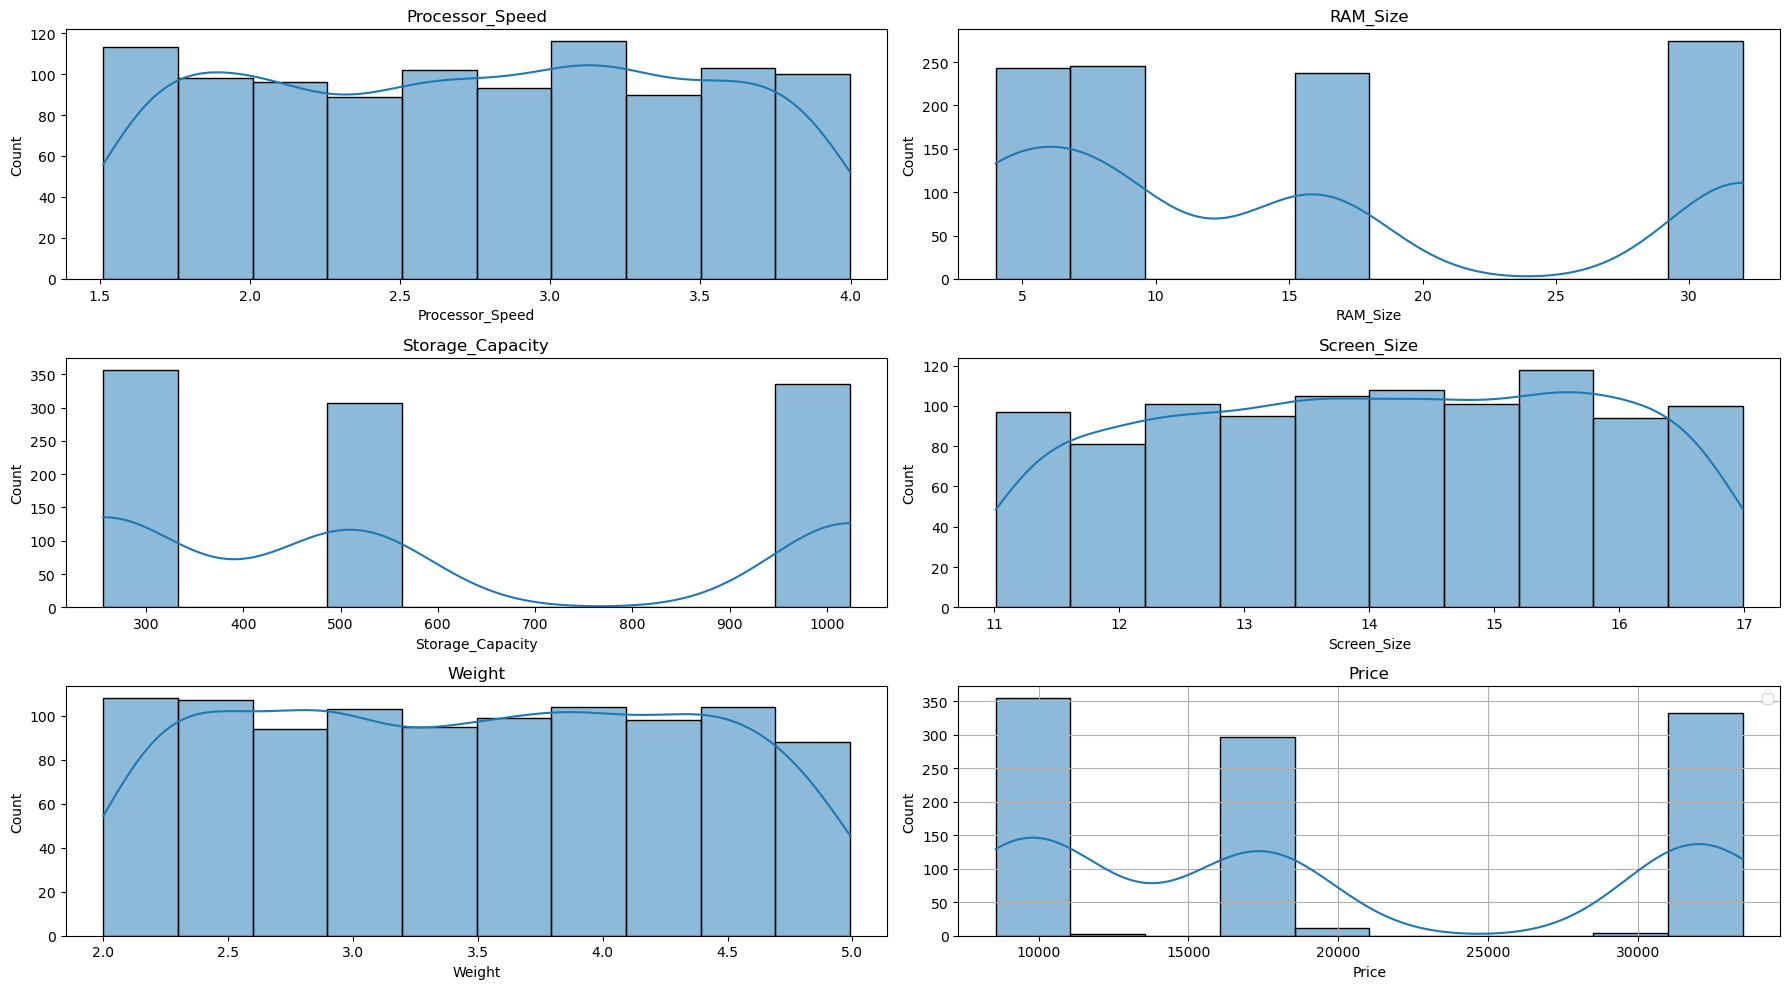

In [12]:
#group plotting 
plt.figure(figsize=(18 ,10))
def plotting(var , num):
    plt.subplot(3 , 2 , num)
    sns.histplot(data = df , x = var , kde = True , bins = 10)
    plt.title(var , fontsize = 12)

plotting('Processor_Speed' , 1)
plotting('RAM_Size' , 2)
plotting('Storage_Capacity' , 3)
plotting('Screen_Size' , 4)
plotting('Weight' , 5)
plotting('Price' , 6)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [13]:
df['Price'].value_counts().head(5)

Price
17395.093065    1
31607.605919    1
9291.023542     1
17436.728334    1
32917.990718    1
Name: count, dtype: int64

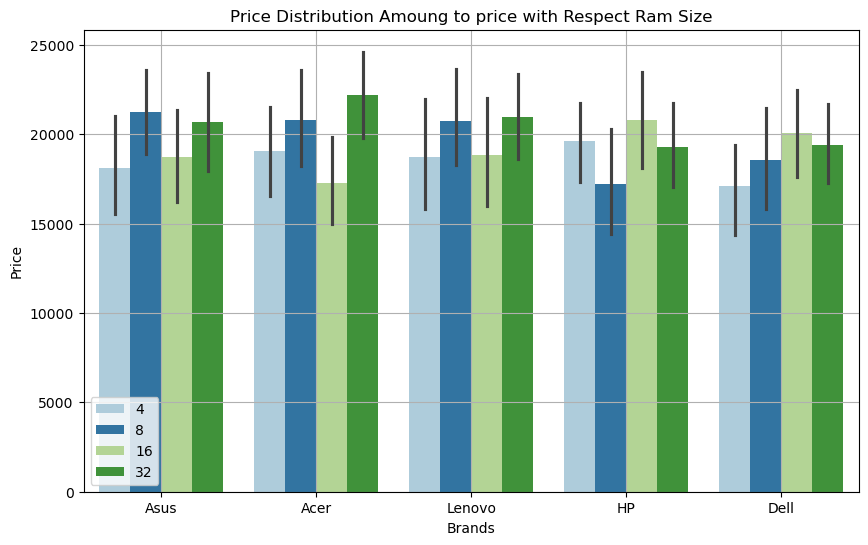

In [14]:
plt.figure(figsize= (10 , 6))
sns.barplot(data = df , y = 'Price' , x = 'Brand' , hue= 'RAM_Size'  , palette= 'Paired')

plt.title('Price Distribution Amoung to price with Respect Ram Size')
plt.xlabel('Brands')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()

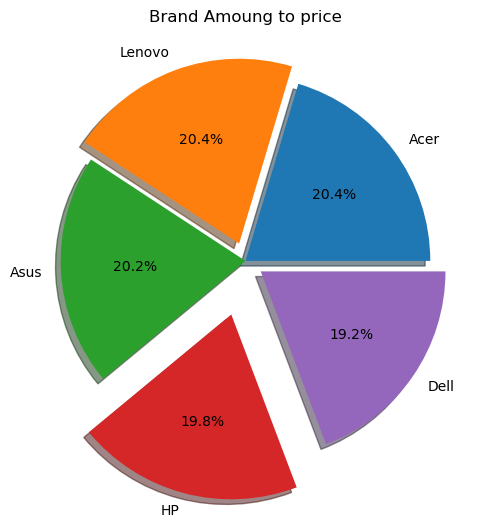

In [15]:
corr = df.groupby('Brand')['Price'].mean().sort_values(ascending= False )

plt.figure(figsize = (10 , 6))
plt.pie(
    corr,
    labels= corr.index,
    autopct= '%.1f%%',
    shadow=True,
    explode=[0. , 0.1 , 0.0 , 0.3 , 0.1]
)

plt.title('Brand Amoung to price')
plt.show()

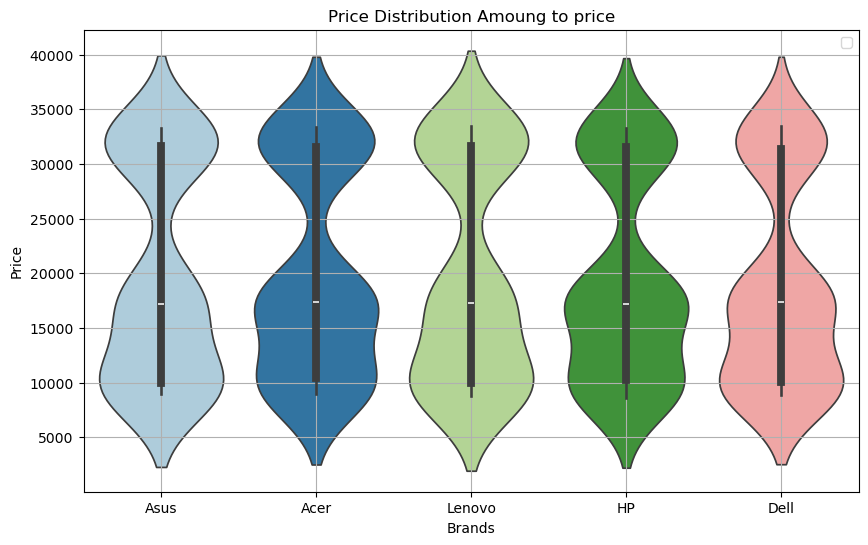

In [16]:
plt.figure(figsize= (10 , 6))
sns.violinplot(data = df , y = 'Price' , x = 'Brand'  , palette= 'Paired')

plt.title('Price Distribution Amoung to price')
plt.xlabel('Brands')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()

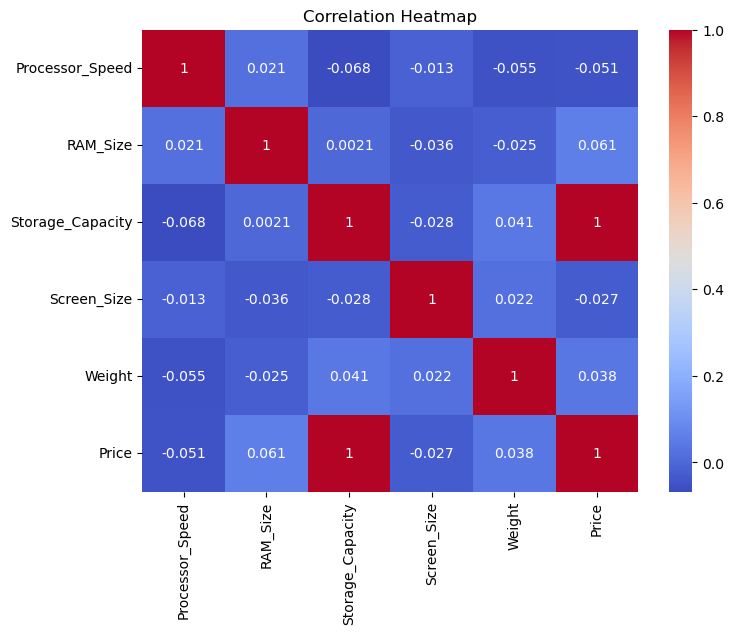

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

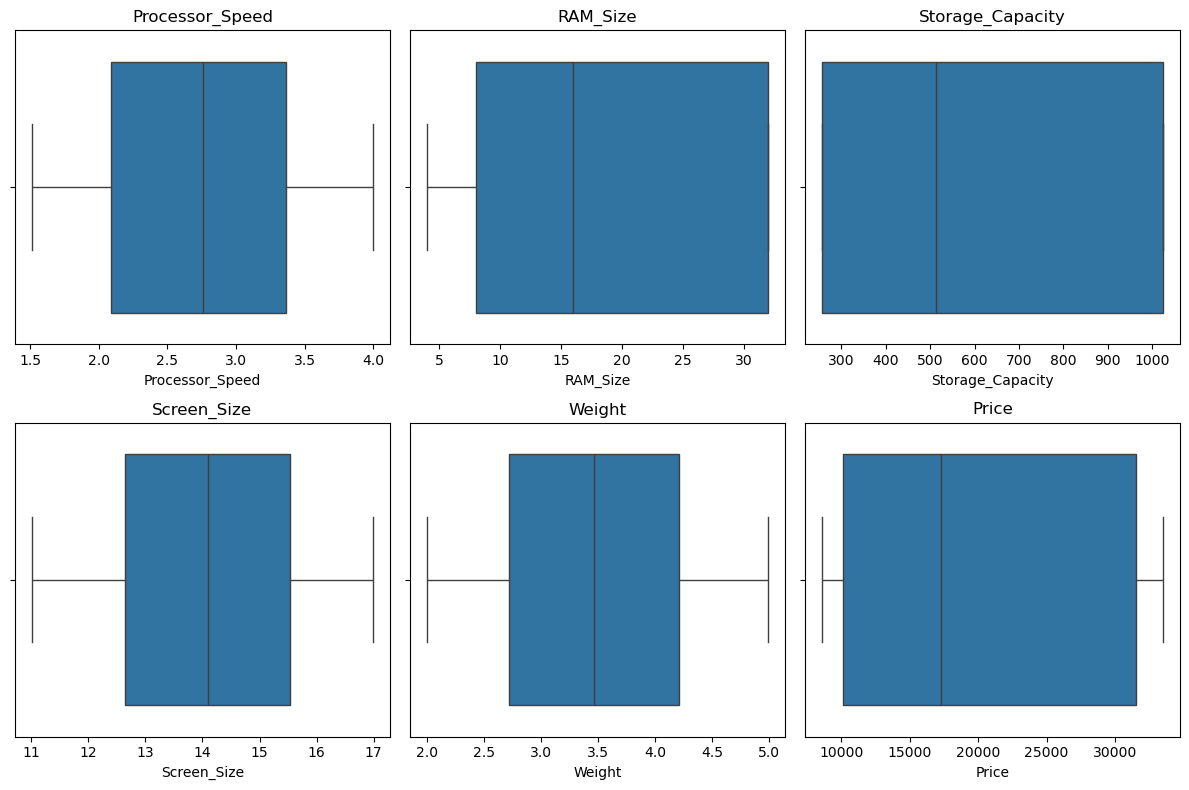

In [18]:
cols = ['Processor_Speed', 'RAM_Size',
        'Storage_Capacity', 'Screen_Size',
        'Weight', 'Price']

plt.figure(figsize=(12,8))

for i, col in enumerate(cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1024,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1024,14.990877,4.193472,32917.990718


In [20]:
df.columns

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight', 'Price'],
      dtype='object')

In [21]:
#columns Tranformation and Standard Scaling and one Hot encoding
cat_col = ['Brand']
num_col = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity', 'Screen_Size', 'Weight']

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('cat' , OneHotEncoder(drop = 'first' , handle_unknown = 'ignore') , cat_col),
        ('num' , StandardScaler() , num_col)
    ]
)

In [22]:
df['Price'].unique().mean()

np.float64(19604.18796323342)

In [23]:
#To See the Standard Scaling Values
x = df.drop('Price' , axis = 1)
x_transformed = preprocessor.fit_transform(x)

x_transformer_df = pd.DataFrame(
    x_transformed,
    columns= preprocessor.get_feature_names_out()
)
x_transformer_df.head(10)

,cat__Brand_Asus,cat__Brand_Dell,cat__Brand_HP,cat__Brand_Lenovo,num__Processor_Speed,num__RAM_Size,num__Storage_Capacity,num__Screen_Size,num__Weight
0,1.0,0.0,0.0,0.0,1.476128,0.045524,-0.248891,-1.684219,-0.953490
1,0.0,0.0,0.0,0.0,0.221788,-1.047057,1.331371,-1.610189,-0.238893
2,0.0,0.0,0.0,1.0,0.671310,-1.047057,-1.039023,-1.292510,-1.660138
3,0.0,0.0,0.0,0.0,1.443251,0.045524,-0.248891,-1.041877,1.278069
4,0.0,0.0,0.0,0.0,0.707499,1.502299,1.331371,0.547843,0.838871
5,0.0,0.0,1.0,0.0,-1.188443,0.045524,-1.039023,-1.239177,1.585655
6,0.0,0.0,0.0,1.0,0.259916,1.502299,-1.039023,-1.374489,1.013646
7,0.0,0.0,0.0,1.0,0.363913,-1.047057,-1.039023,0.898240,-0.607084
8,0.0,0.0,0.0,1.0,-0.260153,-1.047057,-0.248891,0.568637,-0.835115
9,0.0,0.0,0.0,0.0,0.807322,1.502299,-0.248891,-0.260901,0.723039


In [24]:
#Build Pipeline and train the model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline_LR = Pipeline(steps = [
    ('preprocessing' , preprocessor),
    ('model' , LinearRegression(
    fit_intercept=True,
    copy_X=True,
    positive=False
    ))
])

In [25]:
#train and test the model
from sklearn.model_selection import train_test_split

x = df.drop('Price' , axis= 1)
y = df['Price']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state= 42)

In [26]:
#predict the value of using LR
pipeline_LR.fit(x_train , y_train)
LR_pred = pipeline_LR.predict(x_test)
print('Predicted Value Of LR : ' , LR_pred[:10].round(2))

Predicted Value Of LR :  [10823.3  31605.88  9749.71  9350.86 32098.37 31701.9  10433.74 16794.99
 18321.03 32406.2 ]


In [27]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)

(800, 6)
(200, 6)
(800,)


In [28]:
print(len(y_test))
print(len(LR_pred))


200
200


In [29]:
#Report of DATA are come through LR
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mae_LR = mean_absolute_error(y_test, LR_pred)
mse_LR = mean_squared_error(y_test, LR_pred)
r2_LR = r2_score(y_test, LR_pred)
rmse_LR = np.sqrt(mse_LR)

print("Mean Absolute Error :", round(mae_LR, 2))
print("Mean Squared Error  :", round(mse_LR, 2))
print("R2 Score            :", round(r2_LR, 2))
print("Root Mean Squared Error :", round(rmse_LR, 2))

Mean Absolute Error : 170.44
Mean Squared Error  : 45570.25
R2 Score            : 1.0
Root Mean Squared Error : 213.47


In [30]:
print("Train Score:", pipeline_LR.score(x_train, y_train))
print("Test Score :", pipeline_LR.score(x_test, y_test))

Train Score: 0.9994144450796539
Test Score : 0.9994981059247098


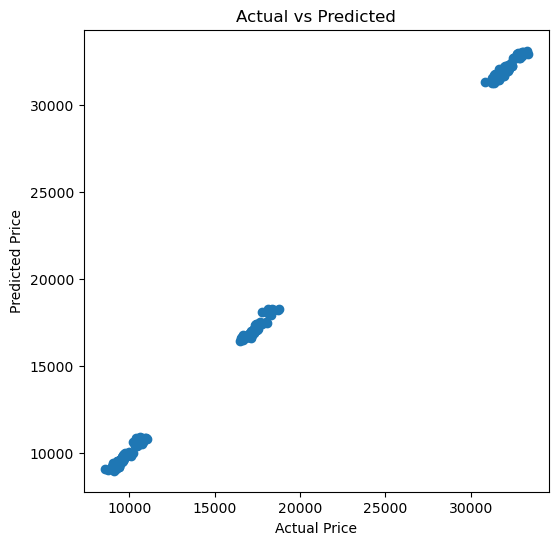

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, LR_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [32]:
##predict the value of using LR
from sklearn.tree import DecisionTreeRegressor

pipeline_DT = Pipeline(steps = [
    ('preprocessing' , preprocessor),
    ('model' , DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42
    ))
])

In [33]:
#predict the valur of DTR
pipeline_DT.fit(x_train , y_train)
DT_pred = pipeline_DT.predict(x_test)
print('Predicted Value : ' , DT_pred[:10].round(2))

Predicted Value :  [10483.98 31624.84  9819.85  9084.37 32024.   31579.97 10719.67 16675.43
 18366.44 32418.23]


In [34]:
#Report of Data are come through the DT
mae_DT = mean_absolute_error(y_test, DT_pred)
mse_DT = mean_squared_error(y_test, DT_pred)
r2_DT = r2_score(y_test, DT_pred)
rmse_DT = np.sqrt(mse_DT)

print("Mean Absolute Error :", round(mae_DT, 2))
print("Mean Squared Error  :", round(mse_DT, 2))
print("R2 Score            :", round(r2_DT, 2))
print("Root Mean Squared Error :", round(rmse_DT, 2))

Mean Absolute Error : 238.65
Mean Squared Error  : 86403.56
R2 Score            : 1.0
Root Mean Squared Error : 293.94


In [35]:
print(x_train.columns)

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight'],
      dtype='object')


In [36]:
print(df.corr(numeric_only=True)['Price'].sort_values(ascending=False))

Price               1.000000
Storage_Capacity    0.997840
RAM_Size            0.061237
Weight              0.038417
Screen_Size        -0.026740
Processor_Speed    -0.050737
Name: Price, dtype: float64


In [37]:
df.groupby('Storage_Capacity')['Price'].mean()

Storage_Capacity
256      9764.373384
512     17430.993066
1024    32044.618434
Name: Price, dtype: float64

In [38]:
#Model Prediction of Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

pipeline_RFR = Pipeline(steps=[
    ('preprocessing' , preprocessor),
    ('model' , RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

In [39]:
pipeline_RFR.fit(x_train , y_train)
RFR_pred = pipeline_RFR.predict(x_test)
print('Predicted Value of RFR : ' , RFR_pred[:10].round(2))

Predicted Value of RFR :  [10555.45 31455.63  9689.78  9219.23 31992.91 31538.84 10639.82 16843.57
 18544.26 32347.86]


In [40]:
#Report of Data are come through the RFR
mae_RFR = mean_absolute_error(y_test, RFR_pred)
mse_RFR = mean_squared_error(y_test, RFR_pred)
r2_RFR = r2_score(y_test, RFR_pred)
rmse_RFR = np.sqrt(mse_RFR)

print("Mean Absolute Error :", round(mae_RFR, 2))
print("Mean Squared Error  :", round(mse_RFR, 2))
print("R2 Score            :", round(r2_RFR, 2))
print("Root Mean Squared Error :", round(rmse_RFR, 2))

Mean Absolute Error : 170.11
Mean Squared Error  : 42251.16
R2 Score            : 1.0
Root Mean Squared Error : 205.55


In [41]:
##Model Prediction of SVR
from sklearn.svm import SVR
pipeline_SVR = Pipeline(steps=[
    ('preprocessing' , preprocessor),
    ('model', SVR(
        kernel='rbf',
        C=100,
        gamma='scale',
        epsilon=0.1
    ))
])

In [42]:
pipeline_SVR.fit(x_train , y_train)
SVR_pred = pipeline_SVR.predict(x_test)
print('Predicted Value of RFR : ' , SVR_pred[:10].round(2))

Predicted Value of RFR :  [16000.88 23260.77 14674.79 14062.43 24913.99 24195.4  16761.53 17276.53
 18555.61 22758.41]


In [43]:
#Report of Data are come through the SVR
mae_SVR = mean_absolute_error(y_test, SVR_pred)
mse_SVR = mean_squared_error(y_test, SVR_pred)
r2_SVR = r2_score(y_test, SVR_pred)
rmse_SVR = np.sqrt(mse_SVR)

print("Mean Absolute Error :", round(mae_SVR, 2))
print("Mean Squared Error  :", round(mse_SVR, 2))
print("R2 Score            :", round(r2_SVR, 2))
print("Root Mean Squared Error :", round(rmse_SVR, 2))

Mean Absolute Error : 4803.77
Mean Squared Error  : 34269897.48
R2 Score            : 0.62
Root Mean Squared Error : 5854.05


In [44]:
comparsion = pd.DataFrame({
    'Model' : ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR'],
    'MAE': [170.44, 238.65, 170.11, 4803.77],
    'RMSE': [213.47, 293.94, 205.55, 5854.05],
    'R2 Score': [0.9995, 0.9990, 0.9996, 0.62]
})
print(comparsion)

               Model      MAE     RMSE  R2 Score
0  Linear Regression   170.44   213.47    0.9995
1      Decision Tree   238.65   293.94    0.9990
2      Random Forest   170.11   205.55    0.9996
3                SVR  4803.77  5854.05    0.6200


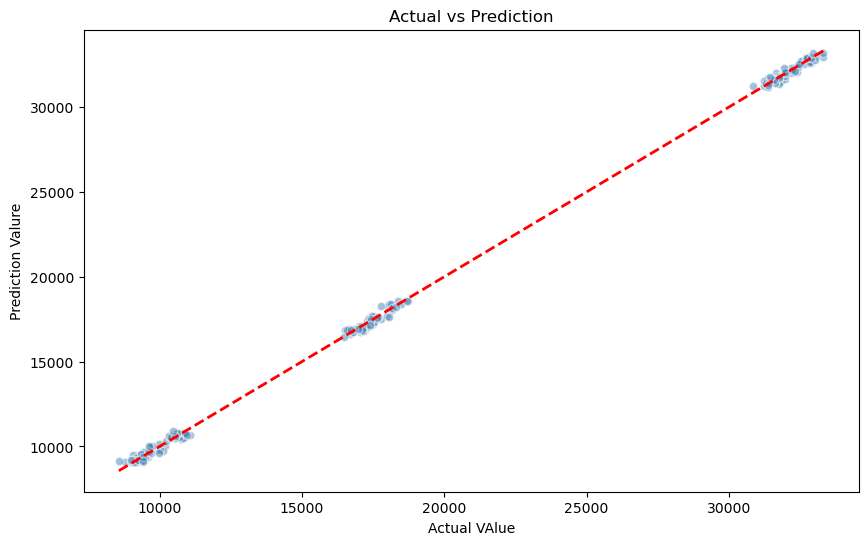

In [47]:
#Actual vs Prediction Graph
plt.figure(figsize = (10 , 6))
plt.scatter(y_test , RFR_pred , alpha = 0.5 , color = 'steelblue', edgecolors = 'white')
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , 'r--' , lw = 2)

plt.title('Actual vs Prediction')
plt.xlabel('Actual VAlue')
plt.ylabel('Prediction Valure')
plt.tight_layout
plt.show()

                 Feature  Important
3      cat__Brand_Lenovo   0.000010
1        cat__Brand_Dell   0.000014
2          cat__Brand_HP   0.000014
0        cat__Brand_Asus   0.000014
8            num__Weight   0.000120
7       num__Screen_Size   0.000140
4   num__Processor_Speed   0.000386
5          num__RAM_Size   0.003542
6  num__Storage_Capacity   0.995761


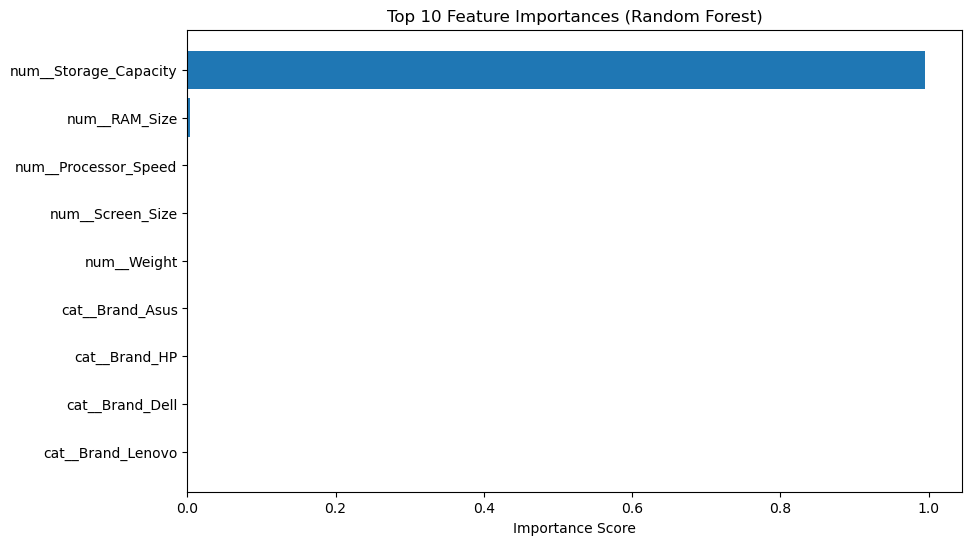

In [51]:
#Find Feature Importance (Random Forest)
feature_name = pipeline_RFR.named_steps['preprocessing'].get_feature_names_out()
importance = pipeline_RFR.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'Feature' : feature_name,
    'Important' : importance,
})

imp_df = imp_df.sort_values('Important' , ascending= True)
print(imp_df)

#ploating Grapgh
plt.figure(figsize=(10 ,6))
plt.barh(
    imp_df['Feature'][:10],
    imp_df['Important'][:10]
)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel("Importance Score")
plt.savefig('Top 10 Feature Importances.png' ,dpi = 300 , bbox_inches = 'tight' )
plt.show()

In [56]:
import joblib
joblib.dump(pipeline_RFR, 'Laptop.pkl')
print('Model Save SuccessFully')

Model Save SuccessFully


In [57]:
model = joblib.load('Laptop.pkl')
pred = model.predict(x_test.iloc[[0]])
print(pred)

[10555.4517806]
